**Importacion Librerias**

In [205]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

**Carga del Dataset**

In [206]:
data = load_breast_cancer()
#data
x = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

In [207]:
x = x[["mean radius", "mean texture"]]

**Diagrama de Dispersion**

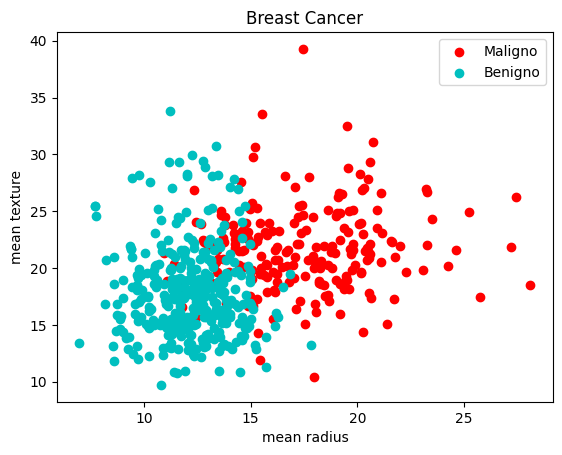

In [208]:
plt.scatter(
    x.loc[y == 0, "mean radius"],
    x.loc[y == 0, "mean texture"],
    color="r",
    label="Maligno")

plt.scatter(
    x.loc[y == 1, "mean radius"],
    x.loc[y == 1, "mean texture"],
    label="Benigno",
    color="c")

plt.xlabel("mean radius")
plt.ylabel("mean texture")
plt.title("Breast Cancer")
plt.legend()
plt.show()

**Dividir los datos**

In [209]:
x = np.array(x)

In [210]:
y[y==0] = -1

In [211]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state = 42, stratify = y)

In [212]:
scaler = StandardScaler()
scaler.fit(x_train)
x_train = scaler.transform(x_train)
x_test = scaler.transform(x_test)
#scaler.fit_transform(x_train)

#**SVM:**

In [213]:
def svm_cost(x, y, beta, c):

  #ones = np.ones(x.shape[0])
  #x = np.column_stack((ones, x))

  fx = x@beta   # x = nx(p+1)   b = (p+1)x1    fx = nx1

  margin = y * fx    #margin = nx1
  hinge_losses = np.maximum(0,1-margin)   #nx1
  #si la prediccion es correcta elige un numero <=0 (mismo signo multiplicado siempre sa positivo
   #(por eso -1 y 1))
  #si es incorrecta por ejemplo 1-(-1) = 2, coge el 2 y le aplica el hiperparametro c
  hinge_loss = np.mean(hinge_losses)

  regularization = 1/2 * (np.linalg.norm(beta[1:]))**2

  loss = regularization + c * hinge_loss

  return loss


In [214]:
def fit_svm(x, y, c, lr, epochs):

  ones = np.ones(x.shape[0])
  x = np.column_stack((ones, x))
  n = len(x)

  historial_costo = []

  beta  = np.zeros(x.shape[1])

  for epoca in range(epochs):

    fx = x@beta

    margin = y * fx    #margin = nx1
    condicion = margin<1

    beta_sin_sesgo = beta.copy()
    beta_sin_sesgo[0] = 0  #evitar que la regularizacion afecte al sesgo

    gradiente_hinge = beta_sin_sesgo + (-c/n) * (x[condicion].T @ y[condicion])
    #gradiente_hinge[0] = 0 +(-c/n * sum(yi))  = -c/n * sumatoria(yi)
    #x vale 1 porque es fila por columna y como esta transpuesta hace fila 1 de x que vale 1
    #por columna de y que tiene las etiquetas. El resultado da una matriz de px1, al dividirlo
    #entre n da el promedio de las y (etiquetas) (posicion 0 del resultado) y lo suma al
    #sesgo que vale 0
    #beta_sin_sesgo[0] = 0 solo apagó la regularización del sesgo,
    #no apagó ni borró su capacidad de actualizarse mediante los errores.

    beta = beta - lr*gradiente_hinge  #aquí se actualiza
    cost = svm_cost(x, y, beta, c)
    historial_costo.append(cost)

  return beta, historial_costo

In [215]:
def predict_svm(x, beta):
    ones = np.ones(x.shape[0])
    x = np.column_stack((ones, x))
    fx = x @ beta
    return np.sign(fx)

**Entrenar**

In [216]:
beta, costs = fit_svm(
                      x_train,
                      y_train,
                      c=100,
                      lr=0.001,
                      epochs=1000)

In [217]:
print(beta)

[ 0.44241758 -1.9417708  -0.52773193]


In [218]:
print(costs[-1] == min(costs))

True


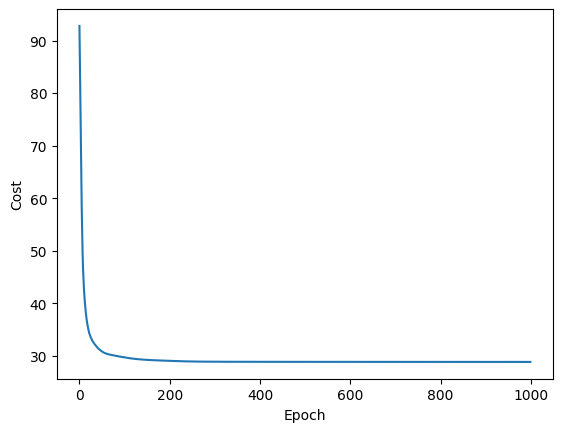

In [219]:
plt.plot(costs)
plt.xlabel("Epoch")
plt.ylabel("Cost")
plt.show()

In [220]:
def plot_svm_decision_boundary(x_original, y, beta):
    #datos escalados
    b = beta[0]
    w1 = beta[1]
    w2 = beta[2] #asumiendo 2 caracteristicas

    #hacer el de dispersion
    plt.scatter(x_original[:, 0], x_original[:, 1], c=y, cmap='bwr', edgecolor='k', s=50)

    #grilla
    x1_min, x1_max = x_original[:, 0].min() - 1, x_original[:, 0].max() + 1
    x1_vals = np.linspace(x1_min, x1_max, 200)

    # Despejar x2 de la ecuación de la frontera: w1*x1 + w2*x2 + b = 0  =>  x2 = (-w1*x1 - b) / w2
    #frontera de decisión (f(x) = 0)
    x2_decision = (-w1 * x1_vals - b) / w2

    # Margen superior (f(x) = 1)  => w1*x1 + w2*x2 + b = 1  =>  x2 = (1 - w1*x1 - b) / w2
    x2_margin_pos = (1 - w1 * x1_vals - b) / w2

    # Margen inferior (f(x) = -1) => w1*x1 + w2*x2 + b = -1 =>  x2 = (-1 - w1*x1 - b) / w2
    x2_margin_neg = (-1 - w1 * x1_vals - b) / w2

    #dibujar lineas
    plt.plot(x1_vals, x2_decision, 'k-', label='Frontera de decisión')
    plt.plot(x1_vals, x2_margin_pos, 'k--', label='Margen (+1)')
    plt.plot(x1_vals, x2_margin_neg, 'k--', label='Margen (-1)')

    plt.xlabel('Característica 1')
    plt.ylabel('Característica 2')
    plt.title('SVM - Frontera y Márgenes')
    plt.legend()
    plt.grid(True)
    plt.show()

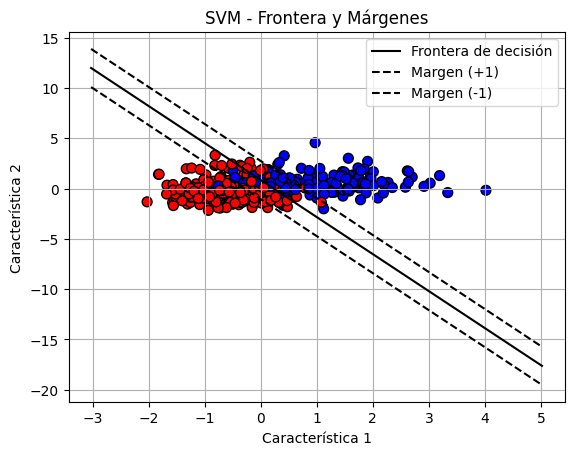

In [221]:
plot_svm_decision_boundary(x_train, y_train, beta)

**Test**

In [222]:
y_pred = predict_svm(x_test, beta)

**Sklearn:**

Accuracy desde cero:   0.8771929824561403
Accuracy sklearn:  0.868421052631579 




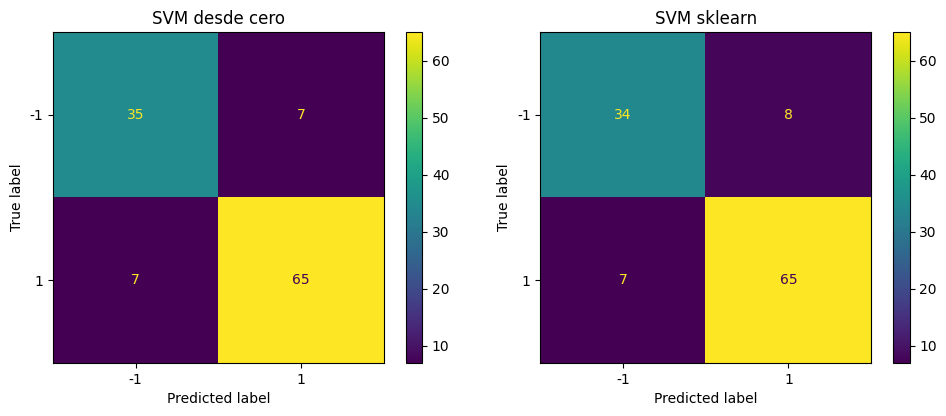

In [241]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

clf = SVC(kernel="linear", C=100)
clf.fit(x_train, y_train)

y_pred_sklearn = clf.predict(x_test)

#comparar accuracy
print("Accuracy desde cero:  ", accuracy_score(y_test, y_pred))
print("Accuracy sklearn: ", accuracy_score(y_test, y_pred_sklearn), "\n"*2)

#matrices de confusion
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels=[-1, 1]).plot(ax=axes[0])
axes[0].set_title("SVM desde cero")

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_sklearn), display_labels=[-1, 1]).plot(ax=axes[1])
axes[1].set_title("SVM sklearn")

plt.tight_layout()
plt.show()

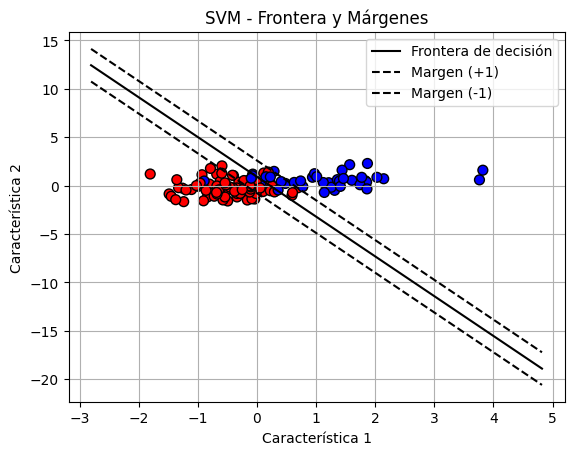

In [245]:
beta_sklearn = np.concatenate([clf.intercept_, clf.coef_[0]])
plot_svm_decision_boundary(x_test, y_test, beta_sklearn)

In [254]:
def plot_svm_decision_boundary2(x_original, y, beta, ax):
    #datos escalados
    b = beta[0]
    w1 = beta[1]
    w2 = beta[2] #asumiendo 2 caracteristicas

    #hacer el de dispersion
    ax.scatter(x_original[:, 0], x_original[:, 1], c=y, cmap='bwr', edgecolor='k', s=50)

    #grilla
    x1_min, x1_max = x_original[:, 0].min() - 1, x_original[:, 0].max() + 1
    x1_vals = np.linspace(x1_min, x1_max, 200)

    # Despejar x2 de la ecuación de la frontera: w1*x1 + w2*x2 + b = 0  =>  x2 = (-w1*x1 - b) / w2
    #frontera de decisión (f(x) = 0)
    x2_decision = (-w1 * x1_vals - b) / w2

    # Margen superior (f(x) = 1)  => w1*x1 + w2*x2 + b = 1  =>  x2 = (1 - w1*x1 - b) / w2
    x2_margin_pos = (1 - w1 * x1_vals - b) / w2

    # Margen inferior (f(x) = -1) => w1*x1 + w2*x2 + b = -1 =>  x2 = (-1 - w1*x1 - b) / w2
    x2_margin_neg = (-1 - w1 * x1_vals - b) / w2

    #dibujar lineas
    ax.plot(x1_vals, x2_decision, 'k-', label='Frontera de decisión')
    ax.plot(x1_vals, x2_margin_pos, 'k--', label='Margen (+1)')
    ax.plot(x1_vals, x2_margin_neg, 'k--', label='Margen (-1)')

    ax.set_xlabel('Característica 1')
    ax.set_ylabel('Característica 2')
    ax.set_title('SVM - Frontera y Márgenes')
    ax.legend()
    ax.grid(True)

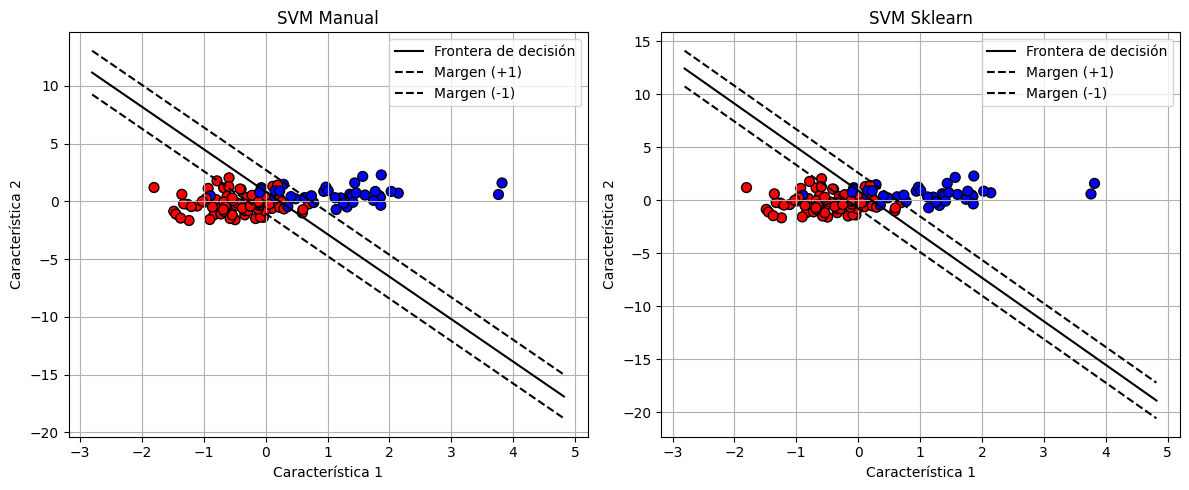

In [258]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

plot_svm_decision_boundary2(x_test, y_test, beta, axes[0])
axes[0].set_title('SVM Manual')

plot_svm_decision_boundary2(x_test, y_test, beta_sklearn, axes[1])
axes[1].set_title('SVM Sklearn')

plt.tight_layout()
plt.show()